# Testing the Components of CONTIGO

- [x] Gravatation Potential 
- [x] Third body acceleration
- [x] [Constants](https://ssd.jpl.nasa.gov/doc/Park.2021.AJ.DE440.pdf)

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
from scipy.integrate import cumulative_simpson

In [3]:
from contigo.forces.GravPot import GravPot
from contigo.forces.ThirdBodyAcc import ThirdBodyAcc

In [41]:
sw_e = pd.read_hdf("./data/ESA_pod.hdf")
sw_o = pd.read_hdf("./data/ore_d.hdf")

efd_e = pd.read_hdf("./data/efd_esa_pod.hdf")
gmat_e = pd.read_hdf("./data/efd_gmat_ekf.hdf")

nmax = 100

spos = sw_e[['x','y','z']].to_numpy()
stime = sw_e['DateTime']
x = sw_e['x'].to_numpy()
y = sw_e['y'].to_numpy()
z = sw_e['z'].to_numpy()

lat = np.arctan2(z,np.sqrt(x*x+y*y))
lon = np.arctan2(y,x)

r = np.sqrt(x*x+y*y+z*z)

### Get the CONTIGO Gravatational Potential

In [5]:
gp_cont = GravPot(r=r,lat=lat,lon=lon,pot_file=r'./data/EIGEN-2.gfc',lmax=100)
gp_cont.calc_pot()

### Get the CONTIGO Third Body Acceleration from the Sun and Moon

In [16]:
tba_cont = ThirdBodyAcc(spos=spos,stime=stime,body=['SUN','MOON'],scale='GPS')  
tba_cont.calc_tba()

Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\de440s.bsp
Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\naif0012.tls
Kernel already loaded - D:\GitHub\contigo_edr\contigo\data\earth_latest_high_prec.bpc


### Compare CONTIGO Values to Orekit Values

Note that Orekit is in meters and CONTIGO is in Km's

In [27]:
print(np.allclose(sw_o['earth_gp'].to_numpy(),gp_cont.gravpot*1000**2))
print(np.allclose(sw_o[['ecef_sn_ax','ecef_sn_ay','ecef_sn_az']], 
                  tba_cont.bd_acc[0,:,:]*1000))
print(np.allclose(sw_o[['ecef_mn_ax','ecef_mn_ay','ecef_mn_az']], 
                  tba_cont.bd_acc[1,:,:]*1000))


True
True
True


## Derive/Plot Effective Density

In [55]:
# Sun and Moon Acceleratios Derived from Orekit
# Positions in ECEF
sn_af = sw_o[['ecef_sn_ax', 'ecef_sn_ay', 'ecef_sn_az']].to_numpy()
mn_af = sw_o[['ecef_mn_ax', 'ecef_mn_ay', 'ecef_mn_az']].to_numpy()

sn_af = tba_cont.bd_acc[0,:,:]*1000.
mn_af = tba_cont.bd_acc[1,:,:]*1000.

edr_pot = gp_cont.gravpot*1000**2

In [56]:
int_sec = (pd.DatetimeIndex(sw_e['DateTime']).to_julian_date()*86400.).to_numpy()
int_sec = int_sec-int_sec.min()

ecef_v = sw_e[['vx','vy','vz']].to_numpy()*1000
ecef_r = sw_e[['x','y','z']].to_numpy()*1000
ecef_xy2 = (sw_e['x'].to_numpy()*1000)**2+(sw_e['y'].to_numpy()*1000)**2
ecef_v2 = (ecef_v*ecef_v).sum(axis=1)
w2 = 5.3174941173225e-09

eci_v = sw_e[['eci_vx','eci_vy','eci_vz']].to_numpy()*1000
srp_a = sw_e[['srp_x','srp_y','srp_z']].to_numpy()*1000

a1 = (sn_af*ecef_v).sum(axis=1)
a2 = (mn_af*ecef_v).sum(axis=1)
a3 = (srp_a*eci_v).sum(axis=1) # this is a fudge factor that we can fix

# denomenator
B = (3.5)*(1.1)/(4.3e+02)
ecef_v3 = np.linalg.norm(ecef_v, axis=1)**3

In [57]:
rolling = int(90*60/10)

edr = ecef_v2/2. - w2*ecef_xy2/2. - edr_pot - \
      cumulative_trapezoid(a1, int_sec, initial=0) - \
      cumulative_trapezoid(a2, int_sec,initial=0)
edr = edr - ecef_v2[0]/2. - w2*ecef_xy2[0]/2. - edr_pot[0]

denom = B*cumulative_trapezoid(ecef_v3, int_sec,initial=0)

cont_edr = pd.DataFrame({'edr':edr, 'denom':denom})
cont_edr['DateTime'] = sw_e['DateTime']
cont_edr['edr_rolling'] = cont_edr['edr'].rolling(rolling).mean()  

In [70]:
edr_ds = ecef_v2[::6]/2. - w2*ecef_xy2[::6]/2. - edr_pot[::6] - \
      cumulative_trapezoid(a1[::6], int_sec[::6], initial=0) - \
      cumulative_trapezoid(a2[::6], int_sec[::6],initial=0)
edr = edr - ecef_v2[0]/2. - w2*ecef_xy2[0]/2. - edr_pot[0] 

Contigo and Orekit all close - True


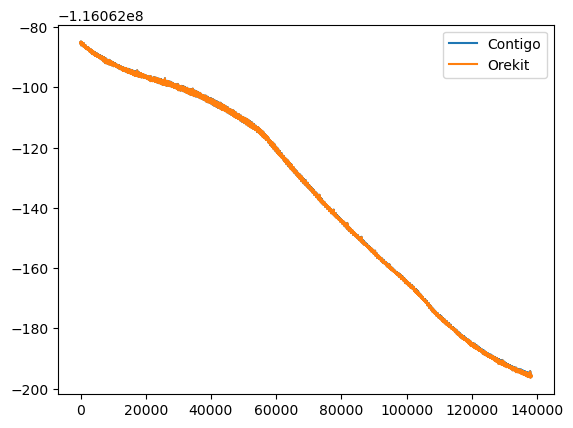

In [66]:
ax = cont_edr['edr'].plot(label='Contigo')
sw_o['edr'].plot(ax=ax, label='Orekit')
ax.legend()

ac = np.allclose(cont_edr['edr'].to_numpy(),sw_o['edr'].to_numpy())

print(f'Contigo and Orekit all close - {ac}')


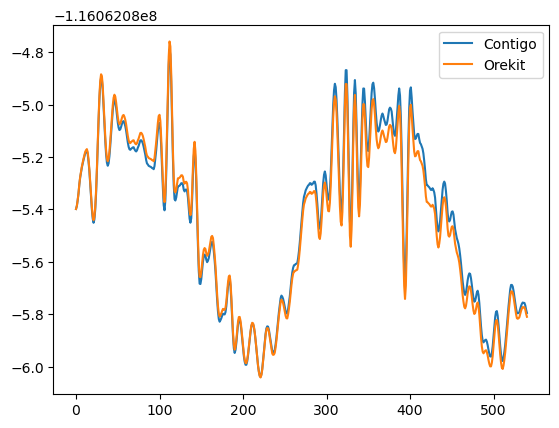

In [69]:
intv = 90*60/10

ax = cont_edr.loc[0:intv,'edr'].plot(label='Contigo')
sw_o.loc[0:intv,'edr'].plot(ax=ax, label='Orekit')
ax.legend()

In [ ]:
plt

In [ ]:
ti = int(90*60/10.) 
cont_efd = pd.DataFrame()
cont_efd['efd'] = -2*(cont_edr['edr_rolling'].shift(ti)-cont_edr['edr_rolling'])/(cont_edr['denom'].shift(ti)-cont_edr['denom']) 
cont_efd['efd'] = cont_efd['efd']*(1000**3)
cont_efd['DateTime'] = cont_edr['DateTime']

In [ ]:
ax = efd_e.plot(x='DateTime',y=['tol_efd','efd_1'],label=['TOLEOS', 'ESA POD (ECI)'])
gmat_e.plot(x='DateTime',y='efd_0',label='GMAT EKF POD (ECI)', ax=ax)
cont_efd.plot(x='DateTime', y='efd', label='CONTIGO (ECEF)', ax=ax)

In [40]:
sw_e.columns

Index(['index', 'sat', 'x', 'y', 'z', 'DateTime', 'vx', 'vy', 'vz',
       'EstSat.EarthFixed.X', 'EstSat.EarthFixed.Y', 'EstSat.EarthFixed.Z',
       'EstSat.EarthFixed.VX', 'EstSat.EarthFixed.VY', 'EstSat.EarthFixed.VZ',
       'EstSat.TAIGregorian', 'eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy',
       'eci_vz', 'eg_x', 'eg_y', 'eg_z', 'sg_x', 'sg_y', 'sg_z', 'mg_x',
       'mg_y', 'mg_z', 'srp_x', 'srp_y', 'srp_z'],
      dtype='str')